In [1]:
import duckdb

duckdb.sql("CREATE VIEW duolingo_flagship AS SELECT * FROM read_csv_auto('../../data/duolingo_flagship.csv')")

df = duckdb.sql("SELECT * FROM duolingo_flagship").df()

In [4]:
history_accuracy = df["history_correct"].values / df["history_seen"].values
history_accuracy

array([0.89655172, 1.        , 1.        , ..., 1.        , 0.74193548,
       0.92307692], shape=(16382,))

In [7]:
import numpy as np
lag_days_log = np.log1p(df["lag_days"].values)
lag_days_log

array([2.39625757, 2.1462821 , 2.07894142, ..., 2.3867424 , 1.95175021,
       0.58611861], shape=(16382,))

Matplotlib is building the font cache; this may take a moment.


<Axes: >

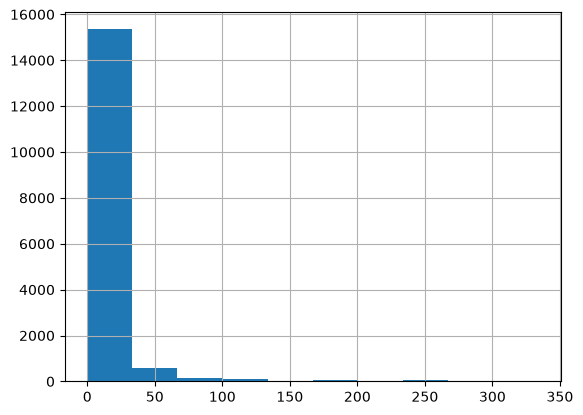

In [8]:
df["lag_days"].hist()

<Axes: >

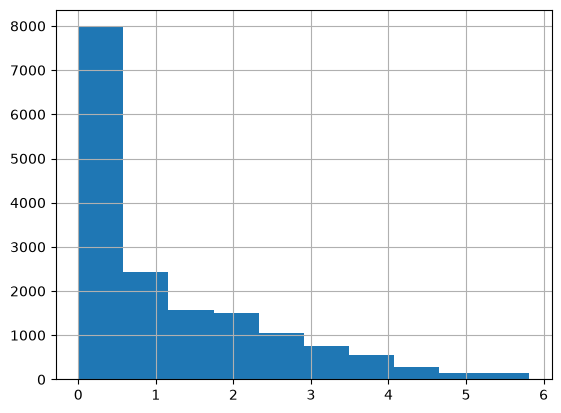

In [9]:
df["lag_days_log"] = lag_days_log
df["lag_days_log"].hist()

In [10]:
df["history_accuracy"] = history_accuracy

In [11]:
df.to_csv("../../data/duolingo_flagship_v2.csv", index=False)